In [ ]:

# --- Setup and configuration ---
DATA_PATH = r"C:\Users\DELL\Downloads\Social-Computing-Notebooks-2\reddit_comments.csv"

# Auto-discover a dataset if DATA_PATH is empty
import os, glob

def auto_discover():
    candidates = []
    for ext in ("*.csv", "*.json", "*.jsonl"):
        candidates.extend(glob.glob(os.path.join("/mnt/data", ext)))
    # Prefer larger files heuristically
    candidates = sorted(candidates, key=lambda p: -os.path.getsize(p))
    return candidates[0] if candidates else ""

if not DATA_PATH:
    DATA_PATH = auto_discover()

print("Detected DATA_PATH:", DATA_PATH if DATA_PATH else "(none found)")


Detected DATA_PATH: C:\Users\DELL\Downloads\Social-Computing-Notebooks-2\reddit_comments.csv


In [4]:

# --- Load dataset ---
import pandas as pd
import json

def load_any(path):
    if not path:
        return pd.DataFrame()
    if path.lower().endswith(".csv"):
        try:
            return pd.read_csv(path)
        except Exception:
            # Try semicolon or tab
            try:
                return pd.read_csv(path, sep=";")
            except Exception:
                return pd.read_csv(path, sep="\t")
    elif path.lower().endswith(".jsonl"):
        # one JSON object per line
        rows = []
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    rows.append(json.loads(line))
                except Exception:
                    pass
        return pd.DataFrame(rows)
    elif path.lower().endswith(".json"):
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            obj = json.load(f)
        if isinstance(obj, list):
            return pd.DataFrame(obj)
        elif isinstance(obj, dict):
            # try common keys
            for k in ("data","items","records","rows","messages","documents"):
                if k in obj and isinstance(obj[k], list):
                    return pd.DataFrame(obj[k])
            # otherwise flatten
            return pd.json_normalize(obj)
    return pd.DataFrame()

df = load_any(DATA_PATH)

# If nothing found, fabricate a tiny demo dataset so the notebook runs end-to-end.
if df.empty:
    demo_texts = [
        "The government plans new transport routes for commuters in Quezon City.",
        "Ateneo students discuss HCI projects and Figma prototypes for Komyuteneo.",
        "Traffic along Katipunan worsened due to road works; commuters expressed frustration.",
        "Football fans in the Philippines celebrate a surprise win in the U-23 qualifiers.",
        "Sentiment around public transit improves after fare discounts and better schedules.",
        "Users posted feedback on the prototype app, praising the ETA and route visuals."
    ]
    df = pd.DataFrame({"text": demo_texts})
    print("No dataset found. Using a small demo corpus (6 rows).")
else:
    print(f"Loaded dataset with shape: {df.shape}")
df.head()


Loaded dataset with shape: (57, 2)


,url,text
0,https://www.reddit.com/r/newsPH/comments/1luqe...,"Misleading title. ""Most Pinoys disagree with i..."
1,https://www.reddit.com/r/newsPH/comments/1luqe...,I disagree. More Pinoys want accountability.
2,https://www.reddit.com/r/newsPH/comments/1luqe...,SWS = Sara Walang Silbi\r\n\r\nHow fitting.
3,https://www.reddit.com/r/newsPH/comments/1luqe...,credible pa ba ang sws survey ngayon?
4,https://www.reddit.com/r/newsPH/comments/1luqe...,Iba-iba result ng survey depende sa nag commis...


In [5]:

# --- Choose a text column heuristically ---
CANDIDATE_TEXT_COLS = [
    "text","Text","body","content","message","comment","selftext",
    "title","full_text","caption","clean_text"
]

text_col = None
for c in CANDIDATE_TEXT_COLS:
    if c in df.columns:
        text_col = c
        break

if text_col is None:
    # Fallback: pick the first object column with strings
    for c in df.columns:
        if df[c].dtype == object:
            text_col = c
            break

if text_col is None:
    raise ValueError("Couldn't find a text column. Please set one manually.")

print("Using text column:", text_col)
print("Sample text:", df[text_col].dropna().astype(str).head(3).tolist())


Using text column: text
Sample text: ['Misleading title. "Most Pinoys disagree with impeachment complaint vs Sara Duterte "\r\n\r\nThe details:  "42 percent of the respondents disagree with the impeachment complaint."\r\n\r\nWhen did 42% mean "Most Pinoys"?   \r\n\r\n  \r\nGo ahead and conduct the trial, the people deserve to know how officials use or misuse taxpayer\'s money in order for them to be ignorant of hidden dealings in government.', 'I disagree.  More Pinoys want accountability.', 'SWS = Sara Walang Silbi\r\n\r\nHow fitting.']


In [6]:

# --- Term-Frequency Language Model (Top 3 words) ---
import re
from sklearn.feature_extraction.text import CountVectorizer

def simple_clean(s: str) -> str:
    s = s.lower()
    s = re.sub(r"http\S+|www\S+", " ", s)      # remove urls
    s = re.sub(r"[^a-z0-9\s]", " ", s)         # keep alphanumerics
    s = re.sub(r"\s+", " ", s).strip()
    return s

texts = df[text_col].dropna().astype(str).apply(simple_clean).tolist()

# basic stopwords list (can be extended)
_stopwords_blob = (
    "a an the and or but if while to from in on at for by of is are was were be been being "
    "it this that these those i you he she they we us our your their my me his her its "
    "with as not no yes do does did have has had will would can could should may might "
    "about into over under out up down than then so such very just also more most other"
)
stopwords = set(_stopwords_blob.split())

def stop_filter(token):
    return token not in stopwords and len(token) > 2 and not token.isdigit()

# Vectorize
cv = CountVectorizer(token_pattern=r"(?u)\b\w+\b")
X = cv.fit_transform(texts)
vocab = cv.get_feature_names_out()

# Sum counts and pick top words (excluding stopwords)
import numpy as np
counts = np.asarray(X.sum(axis=0)).ravel()
freqs = sorted([(vocab[i], int(counts[i])) for i in range(len(vocab))], key=lambda x: -x[1])

top_words = []
for w, c in freqs:
    if stop_filter(w):
        top_words.append((w, c))
    if len(top_words) >= 3:
        break

print("Top 3 words (word, count):", top_words)


Top 3 words (word, count): [('ang', 20), ('mga', 12), ('impeachment', 11)]


In [7]:

# --- Train static Word2Vec and find most similar words for the top 3 ---
from gensim.models import Word2Vec

# Tokenize for Word2Vec
tokenized = [t.split() for t in texts]

# Small, fast Word2Vec just for demo; adjust as needed
w2v = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=1, workers=2, sg=1, epochs=20)

neighbors = {}
for w, _ in top_words:
    if w in w2v.wv.key_to_index:
        neighbors[w] = w2v.wv.most_similar(w, topn=10)
    else:
        neighbors[w] = []

for w, sims in neighbors.items():
    print(f"\nMost similar to '{w}':")
    for term, score in sims:
        print(f"  {term:20s}  {score:.3f}")



Most similar to 'ang':
  a                     0.998
  the                   0.998
  impeachment           0.998
  in                    0.998
  to                    0.998
  is                    0.998
  na                    0.998
  and                   0.998
  of                    0.998
  sa                    0.998

Most similar to 'mga':
  the                   0.998
  a                     0.998
  sa                    0.998
  ang                   0.998
  ng                    0.998
  in                    0.997
  to                    0.997
  na                    0.997
  yan                   0.997
  t                     0.997

Most similar to 'impeachment':
  the                   0.998
  is                    0.998
  ang                   0.998
  of                    0.998
  sa                    0.998
  a                     0.998
  to                    0.998
  it                    0.998
  s                     0.998
  country               0.998


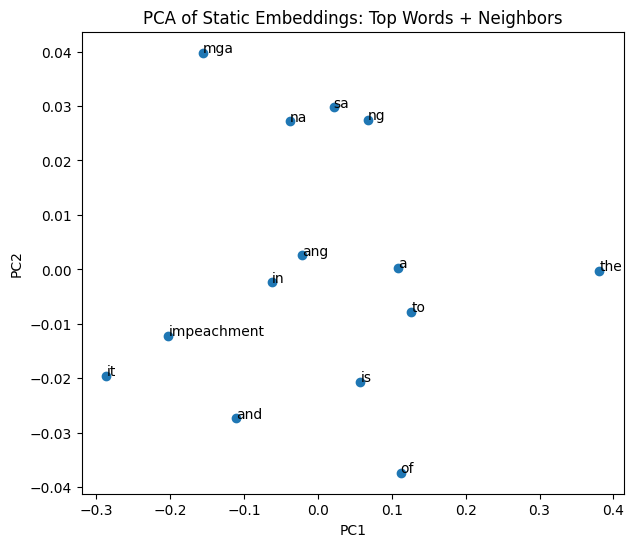

In [8]:

# --- PCA of the top words + their neighbors ---
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

plot_words = set([w for w,_ in top_words])
for _, sims in neighbors.items():
    for term,_ in sims[:8]:  # take first 8 neighbors per top word to avoid clutter
        plot_words.add(term)

# collect vectors
labels = []
vecs = []
for w in plot_words:
    if w in w2v.wv.key_to_index:
        labels.append(w)
        vecs.append(w2v.wv[w])
vecs = np.vstack(vecs)

# PCA to 2D
pca = PCA(n_components=2, random_state=0)
pts = pca.fit_transform(vecs)

# plot (one plot, no specific colors)
plt.figure(figsize=(7,6))
plt.scatter(pts[:,0], pts[:,1])
for i, label in enumerate(labels):
    plt.annotate(label, (pts[i,0], pts[i,1]))
plt.title("PCA of Static Embeddings: Top Words + Neighbors")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [9]:
# --- Hugging Face BERT/RoBERTa Sentiment ---
from transformers import pipeline
import pandas as pd

# Choose one of these models:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"   # better for social media / mixed lang
# MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"  # lightweight English-only

BATCH_SIZE = 64
MAX_ROWS = 1000

subset = df[text_col].dropna().astype(str).head(MAX_ROWS).tolist()

# Build pipeline (device=-1 → CPU, change to 0 if you have GPU + CUDA)
clf = pipeline("sentiment-analysis", model=MODEL_NAME, device=-1, truncation=True)
preds = clf(subset, batch_size=BATCH_SIZE)

# Convert to DataFrame
out = pd.DataFrame(preds)
out["text"] = subset

display(out.head())

# Label distribution
print("Sentiment label distribution:\n", out["label"].value_counts(dropna=False))


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

c:\Users\DELL\Downloads\Social-Computing-Notebooks-2\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DELL\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment-latest. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

,label,score,text
0,negative,0.676521,"Misleading title. ""Most Pinoys disagree with i..."
1,neutral,0.512297,I disagree. More Pinoys want accountability.
2,neutral,0.538548,SWS = Sara Walang Silbi\r\n\r\nHow fitting.
3,neutral,0.857812,credible pa ba ang sws survey ngayon?
4,neutral,0.879580,Iba-iba result ng survey depende sa nag commis...


Sentiment label distribution:
 label
neutral     32
negative    23
positive     2
Name: count, dtype: int64


In [10]:

# --- Hugging Face BERT-based Sentiment ---
# We'll try a compact model. If offline or uncached, we fall back to VADER.

from typing import List
BATCH_SIZE = 64
MAX_ROWS = 1000  # adjust as needed

subset = df[text_col].dropna().astype(str).head(MAX_ROWS).tolist()

preds = None
used_model = None
error_msg = None

try:
    from transformers import pipeline
    used_model = "cardiffnlp/twitter-roberta-base-sentiment-latest"
    clf = pipeline("sentiment-analysis", model=used_model, truncation=True)
    preds = clf(subset, batch_size=BATCH_SIZE)
except Exception as e:
    error_msg = str(e)
    preds = None

import pandas as pd

if preds is None:
    print("⚠️ Could not run the Hugging Face model (likely offline or missing cache).")
    if error_msg:
        print("Reason:", error_msg[:300], "...")
    print("Falling back to VADER (lexicon-based) so you still get a sentiment view.")
    try:
        from nltk.sentiment import SentimentIntensityAnalyzer
        import nltk
        try:
            nltk.data.find('sentiment/vader_lexicon.zip')
        except LookupError:
            nltk.download('vader_lexicon')
        sia = SentimentIntensityAnalyzer()
        vader_scores = [sia.polarity_scores(t) for t in subset]
        out = pd.DataFrame(vader_scores)
        out["text"] = subset
        display(out.head())
    except Exception as e2:
        print("VADER also failed:", e2)
else:
    out = pd.DataFrame(preds)
    out["text"] = subset
    display(out.head())

# Summary
if 'label' in out.columns:
    print("Sentiment label distribution:\n", out['label'].value_counts(dropna=False))
elif 'compound' in out.columns:
    print("VADER sentiment summary (compound scores):")
    print(out["compound"].describe())


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


,label,score,text
0,negative,0.676521,"Misleading title. ""Most Pinoys disagree with i..."
1,neutral,0.512297,I disagree. More Pinoys want accountability.
2,neutral,0.538548,SWS = Sara Walang Silbi\r\n\r\nHow fitting.
3,neutral,0.857812,credible pa ba ang sws survey ngayon?
4,neutral,0.879580,Iba-iba result ng survey depende sa nag commis...


Sentiment label distribution:
 label
neutral     32
negative    23
positive     2
Name: count, dtype: int64
